# 11 — Cooling Cycle Analysis (Production Logs)

**Purpose:** Parse 3 production log files cycle-by-cycle. Compare ML-based (LGBM)
vs trajectory-based (shadow) pre-cooling precision. Analyse cooling effectiveness,
binary search convergence, cycle gate behavior, and parameter evolution.

**Logs analyzed:**
1. `2026-05-31T15-43-28` — Recovery phase, 7 cycles
2. `2026-06-01T10-19-29` — Active cooling, higher demand
3. `2026-06-01T19-58-36` — Dynamic control, τ explosion visible

**Key Question:** Is trajectory-based pre-cooling more reliable and easier to handle
than the LGBM classifier? The LGBM probability appears near-constant (~0.42).

In [1]:
import sys, os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (16, 6)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
LOG_DIR = PROJECT_ROOT / "Logs_and_models"

LOG_FILES = sorted(LOG_DIR.glob("74f4b7ef_ml_heating_underfloor_2026-0*.log"))
print(f"Found {len(LOG_FILES)} log files:")
for f in LOG_FILES:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} ({size_kb:.0f} KB)")

Found 4 log files:
  74f4b7ef_ml_heating_underfloor_2026-05-16T07-07-41.473Z.log (681 KB)
  74f4b7ef_ml_heating_underfloor_2026-05-31T15-43-28.440Z.log (1456 KB)
  74f4b7ef_ml_heating_underfloor_2026-06-01T10-19-29.568Z.log (1213 KB)
  74f4b7ef_ml_heating_underfloor_2026-06-01T19-58-36.840Z.log (1419 KB)


## Phase A: Log Parsing

Extract structured cycle data from raw log text using regex patterns.

In [2]:
def parse_cooling_cycles(log_path):
    """Parse a single log file and extract cooling cycle data."""
    with open(log_path, "r", encoding="utf-8", errors="replace") as f:
        text = f.read()
    
    cycles = []
    current = {}
    
    for line in text.split("\n"):
        # Cycle start
        m = re.search(r"CYCLE (\d+) START: (\d{2}:\d{2}:\d{2})", line)
        if m:
            if current.get("cycle_num"):
                cycles.append(current)
            current = {"cycle_num": int(m.group(1)), "start_time": m.group(2)}
            continue
        
        # Cooling mode detection
        if "Cooling mode active" in line or "COOLING MODE" in line:
            current["is_cooling"] = True
        
        # Cooling target
        m = re.search(r"cooling target entity: ([\d.]+)", line)
        if m:
            current["target_temp"] = float(m.group(1))
        
        # LGBM pre-cool
        m = re.search(r"LGBM PRE-COOL (\w+).*?p=([\d.]+).*?thr=([\d.]+).*?max=([\d.]+)", line)
        if m:
            current["lgbm_activated"] = m.group(1) == "ACTIVATED"
            current["lgbm_prob"] = float(m.group(2))
            current["lgbm_threshold"] = float(m.group(3))
            current["lgbm_peak_temp"] = float(m.group(4))
        
        # Trajectory (shadow)
        m = re.search(r"SHADOW.*?risk=(\w+)\s+peak=([\d.]+).*?in ([\d.]+)h", line)
        if m:
            current["traj_risk"] = m.group(1) == "True"
            current["traj_peak"] = float(m.group(2))
            current["traj_peak_hours"] = float(m.group(3))
        
        # PRE-COOL activation (trajectory)
        m = re.search(r"PRE-COOL (\w+):.*?room ([\d.]+).*?target ([\d.]+).*?peak_outdoor=([\d.]+)", line)
        if m and "LGBM" not in line:
            current["precool_activated"] = m.group(1) == "ACTIVATED"
            current["room_temp"] = float(m.group(2))
            current["precool_target"] = float(m.group(3))
        
        # Binary search
        m = re.search(r"Binary search start: target=([\d.]+).*?current=([\d.]+).*?range=([\d.]+)-([\d.]+)", line)
        if m:
            current["bs_target"] = float(m.group(1))
            current["bs_current"] = float(m.group(2))
            current["bs_range_min"] = float(m.group(3))
            current["bs_range_max"] = float(m.group(4))
        
        m = re.search(r"Binary search converged after (\d+) iterations: ([\d.]+).*?predicted.*?([\d.]+).*?error: ([+-]?[\d.]+)", line)
        if m:
            current["bs_iterations"] = int(m.group(1))
            current["bs_outlet"] = float(m.group(2))
            current["bs_predicted"] = float(m.group(3))
            current["bs_error"] = float(m.group(4))
        
        # Newton correction
        m = re.search(r"\[Newton\].*?outlet ([\d.]+)", line)
        if m:
            current["newton_outlet"] = float(m.group(1))
        m = re.search(r"\[Newton\].*?T=([+-]?[\d.]+)", line)
        if m:
            current["newton_delta"] = float(m.group(1))
        
        # Cooling cycle gate
        m = re.search(r"Cooling cycle gate: (\w+)", line)
        if m:
            current["gate_state"] = m.group(1)
        
        # Equilibrium physics
        m = re.search(r"Equilibrium physics:.*?heat_loss_coeff=([\d.]+).*?outlet_eff=([\d.]+).*?equilibrium=([\d.]+)", line)
        if m:
            current["eq_hlc"] = float(m.group(1))
            current["eq_oe"] = float(m.group(2))
            current["eq_temp"] = float(m.group(3))
        
        # Model wrapper params
        m = re.search(r"Wrapper params: U=([\d.]+), eff=([\d.]+), tau=([\d.]+)", line)
        if m:
            current["param_hlc"] = float(m.group(1))
            current["param_oe"] = float(m.group(2))
            current["param_tau"] = float(m.group(3))
        
        # Final outlet (from HA sensor)
        m = re.search(r"sensor\.ml_vorlauftemperatur.*?'state': '([\d.]+)'", line)
        if m:
            current["final_outlet"] = float(m.group(1))
        
        # Prediction output
        m = re.search(r"Prediction:.*?Current ([\d.]+).*?Target ([\d.]+).*?outlet: ([\d.]+)", line)
        if m:
            current["pred_current"] = float(m.group(1))
            current["pred_target"] = float(m.group(2))
            current["pred_outlet"] = float(m.group(3))
        
        # Prediction feedback
        m = re.search(r"Prediction feedback: error=([\d.]+).*?confidence=([\d.]+)", line)
        if m:
            current["feedback_error"] = float(m.group(1))
            current["feedback_confidence"] = float(m.group(2))
        
        # Added prediction (previous cycle validation)
        m = re.search(r"Added prediction: pred=([\d.]+), actual=([\d.]+), error=([\d.]+)", line)
        if m:
            current["prev_predicted"] = float(m.group(1))
            current["prev_actual"] = float(m.group(2))
            current["prev_error"] = float(m.group(3))
        
        # Channel learning
        m = re.search(r"heat_pump parameter update.*?delta_t_floor: [\d.]+.([\d.]+).*?heat_loss_coefficient: [\d.]+.([\d.]+).*?outlet_effectiveness: [\d.]+.([\d.]+).*?thermal_time_constant: [\d.]+.([\d.]+)", line)
        if m:
            current["learn_dtf"] = float(m.group(1))
            current["learn_hlc"] = float(m.group(2))
            current["learn_oe"] = float(m.group(3))
            current["learn_tau"] = float(m.group(4))
        
        # MAE/RMSE
        m = re.search(r"sensor\.ml_model_mae.*?'state': '([\d.]+)'", line)
        if m:
            current["mae"] = float(m.group(1))
        m = re.search(r"sensor\.ml_model_rmse.*?'state': '([\d.]+)'", line)
        if m:
            current["rmse"] = float(m.group(1))
        
        # Outdoor temp from features
        m = re.search(r"'outdoor_temp': ([\d.]+)", line)
        if m and "sensor.ml_heating_features" in line:
            current["feat_outdoor"] = float(m.group(1))
        
        # Cycle end
        m = re.search(r"CYCLE \d+ END.*?duration: ([\d.]+)s", line)
        if m:
            current["duration_s"] = float(m.group(1))
    
    # Don't forget last cycle
    if current.get("cycle_num"):
        cycles.append(current)
    
    return [c for c in cycles if c.get("is_cooling")]

# Parse all log files
all_cycles = []
for log_path in LOG_FILES:
    cycles = parse_cooling_cycles(log_path)
    for c in cycles:
        c["log_file"] = log_path.name
    all_cycles.extend(cycles)
    print(f"{log_path.name}: {len(cycles)} cooling cycles")

df_cycles = pd.DataFrame(all_cycles)
print(f"\nTotal cooling cycles: {len(df_cycles)}")
print(f"Columns: {list(df_cycles.columns)}")
avail = [c for c in ["cycle_num", "log_file", "gate_state", "bs_iterations",
         "final_outlet", "lgbm_prob", "traj_risk", "feedback_error"] if c in df_cycles.columns]
df_cycles[avail].head(20)

74f4b7ef_ml_heating_underfloor_2026-05-16T07-07-41.473Z.log: 0 cooling cycles
74f4b7ef_ml_heating_underfloor_2026-05-31T15-43-28.440Z.log: 63 cooling cycles
74f4b7ef_ml_heating_underfloor_2026-06-01T10-19-29.568Z.log: 33 cooling cycles
74f4b7ef_ml_heating_underfloor_2026-06-01T19-58-36.840Z.log: 61 cooling cycles

Total cooling cycles: 157
Columns: ['cycle_num', 'start_time', 'learn_dtf', 'learn_hlc', 'learn_oe', 'learn_tau', 'mae', 'rmse', 'is_cooling', 'target_temp', 'lgbm_activated', 'lgbm_prob', 'lgbm_threshold', 'lgbm_peak_temp', 'traj_risk', 'traj_peak', 'traj_peak_hours', 'param_hlc', 'param_oe', 'param_tau', 'bs_target', 'bs_current', 'bs_range_min', 'bs_range_max', 'eq_hlc', 'eq_oe', 'eq_temp', 'gate_state', 'pred_current', 'pred_target', 'pred_outlet', 'final_outlet', 'feat_outdoor', 'duration_s', 'log_file', 'feedback_error', 'feedback_confidence', 'prev_predicted', 'prev_actual', 'prev_error', 'precool_activated', 'room_temp', 'precool_target', 'newton_outlet', 'newton_delt

,cycle_num,log_file,gate_state,final_outlet,lgbm_prob,traj_risk,feedback_error
0,38,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,19.0,0.424,True,NaN
1,39,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,19.0,NaN,True,NaN
2,40,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,20.0,NaN,True,0.042
3,41,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,18.0,0.424,True,0.015
4,42,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,18.0,0.596,True,NaN
5,43,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,18.0,1.000,True,NaN
6,44,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,18.0,1.000,True,NaN
7,45,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,18.0,0.424,True,NaN
8,46,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,18.0,0.417,True,NaN
9,47,74f4b7ef_ml_heating_underfloor_2026-05-31T15-4...,RUNNING,18.0,0.424,True,0.097


## Phase B: Cycle-by-Cycle Dashboard

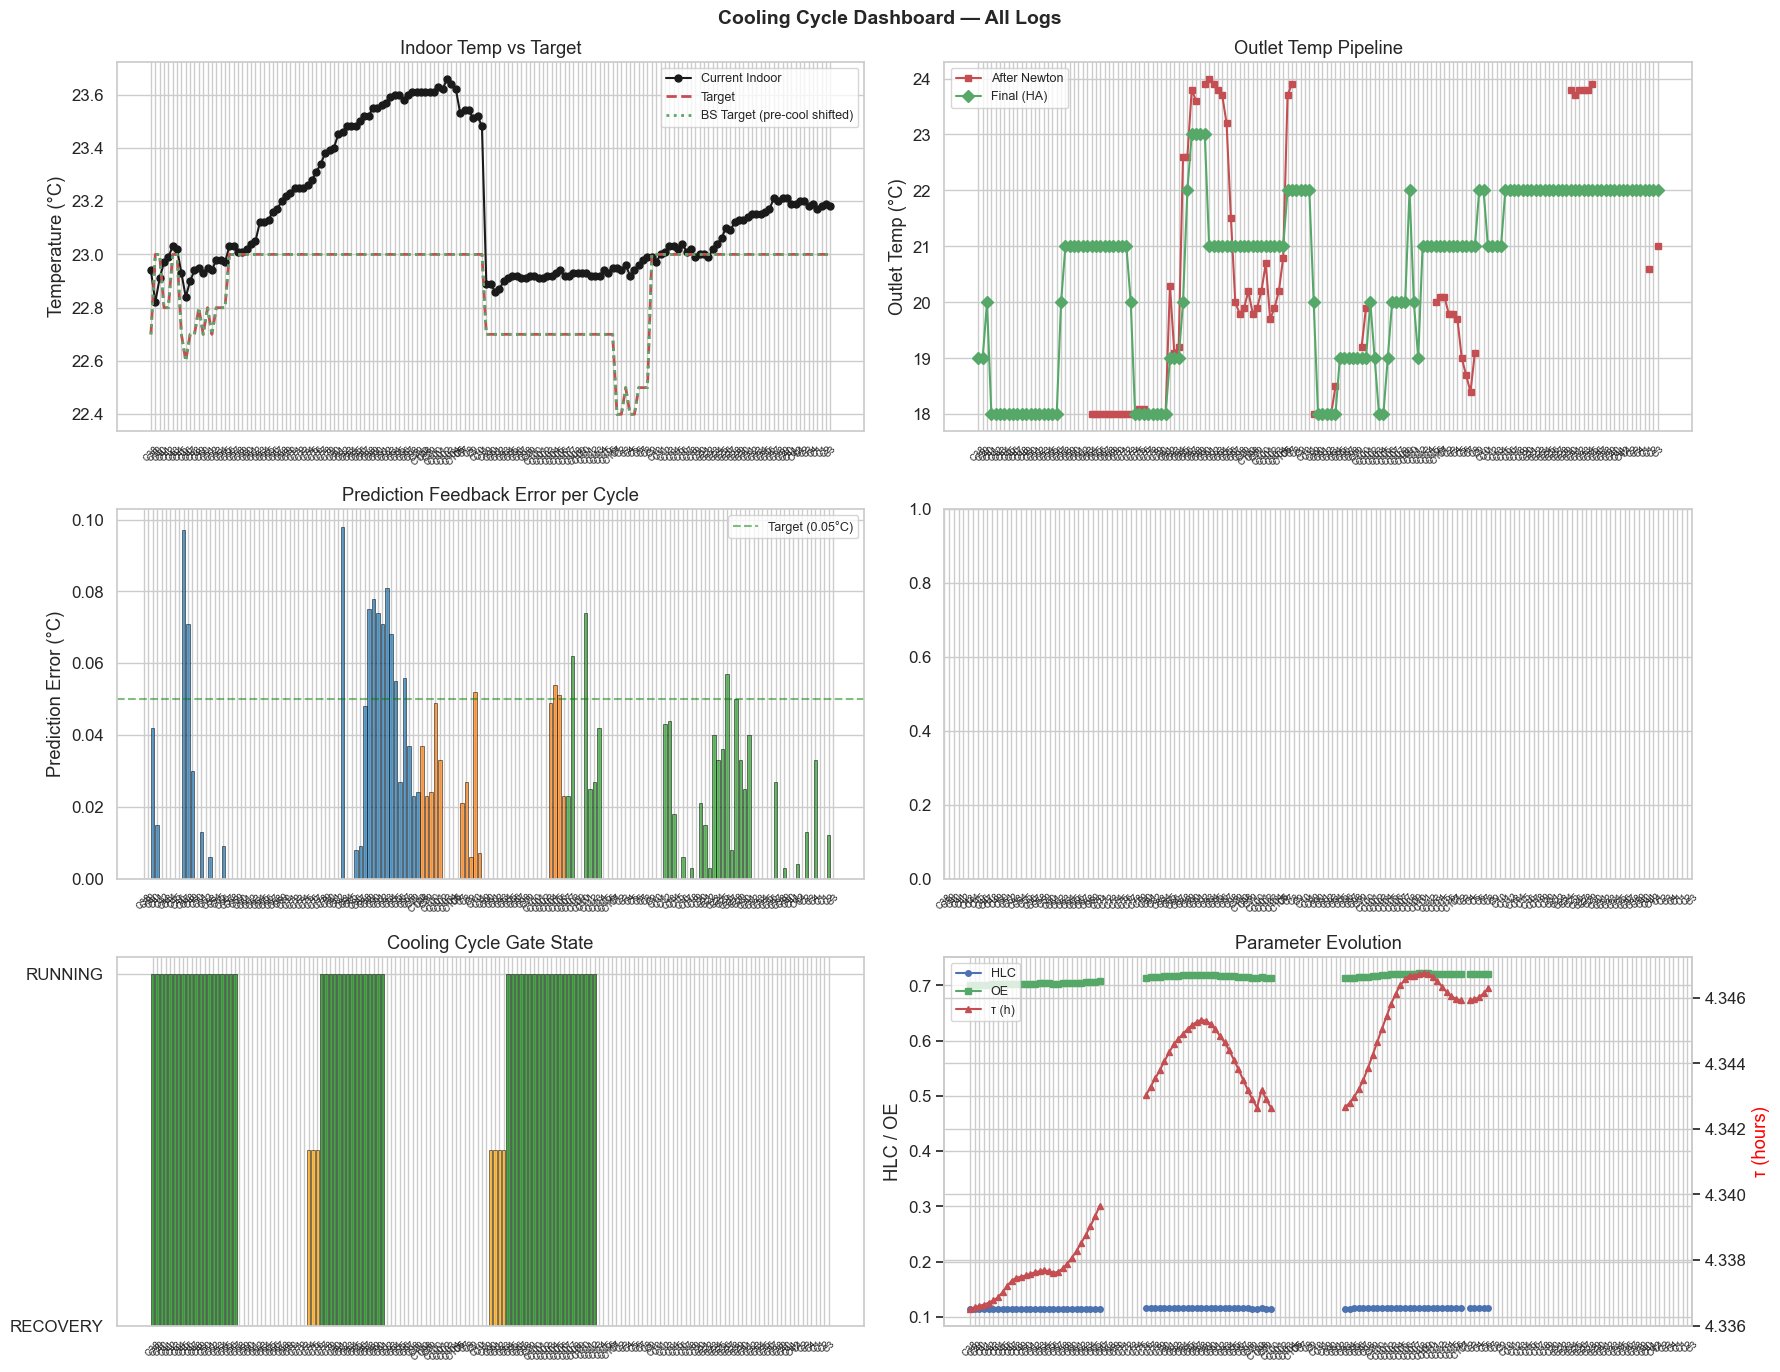

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
x = range(len(df_cycles))
labels = [f"C{int(r['cycle_num'])}" for _, r in df_cycles.iterrows()]

# Color by log file
log_colors = {}
for i, lf in enumerate(df_cycles["log_file"].unique()):
    log_colors[lf] = ["#1f77b4", "#ff7f0e", "#2ca02c"][i % 3]
colors = [log_colors[lf] for lf in df_cycles["log_file"]]

# 1) Indoor temp vs target
ax = axes[0, 0]
if "pred_current" in df_cycles.columns:
    ax.plot(x, df_cycles["pred_current"], "ko-", ms=5, label="Current Indoor")
if "pred_target" in df_cycles.columns:
    ax.plot(x, df_cycles["pred_target"], "r--", lw=2, label="Target")
if "bs_target" in df_cycles.columns:
    ax.plot(x, df_cycles["bs_target"], "g:", lw=2, label="BS Target (pre-cool shifted)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Indoor Temp vs Target")
ax.legend(fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, fontsize=7)

# 2) Outlet temps
ax = axes[0, 1]
if "bs_outlet" in df_cycles.columns:
    ax.plot(x, df_cycles["bs_outlet"], "b^-", ms=5, label="Binary Search")
if "newton_outlet" in df_cycles.columns:
    ax.plot(x, df_cycles["newton_outlet"], "rs-", ms=5, label="After Newton")
if "final_outlet" in df_cycles.columns:
    ax.plot(x, df_cycles["final_outlet"], "gD-", ms=6, label="Final (HA)")
ax.set_ylabel("Outlet Temp (°C)")
ax.set_title("Outlet Temp Pipeline")
ax.legend(fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, fontsize=7)

# 3) Prediction error
ax = axes[1, 0]
if "feedback_error" in df_cycles.columns:
    bars = ax.bar(x, df_cycles["feedback_error"], color=colors, alpha=0.7, edgecolor="black", lw=0.5)
    ax.axhline(0.05, color="green", ls="--", alpha=0.5, label="Target (0.05°C)")
    ax.set_ylabel("Prediction Error (°C)")
    ax.set_title("Prediction Feedback Error per Cycle")
    ax.legend(fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, fontsize=7)

# 4) Binary search iterations
ax = axes[1, 1]
if "bs_iterations" in df_cycles.columns:
    ax.bar(x, df_cycles["bs_iterations"], color=colors, alpha=0.7, edgecolor="black", lw=0.5)
    ax.set_ylabel("Iterations")
    ax.set_title("Binary Search Iterations")
    ax.axhline(1, color="green", ls="--", alpha=0.5, label="Ideal (1)")
    ax.legend(fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, fontsize=7)

# 5) Gate state
ax = axes[2, 0]
if "gate_state" in df_cycles.columns:
    gate_map = {"RUNNING": 1, "RECOVERY": 0}
    gate_vals = df_cycles["gate_state"].map(gate_map).fillna(0.5)
    ax.bar(x, gate_vals, color=["green" if v == 1 else "orange" for v in gate_vals],
           alpha=0.7, edgecolor="black", lw=0.5)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["RECOVERY", "RUNNING"])
    ax.set_title("Cooling Cycle Gate State")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, fontsize=7)

# 6) Parameter evolution
ax = axes[2, 1]
if "learn_hlc" in df_cycles.columns:
    ax2 = ax.twinx()
    ln1 = ax.plot(x, df_cycles["learn_hlc"], "b-o", ms=4, label="HLC")
    ln2 = ax.plot(x, df_cycles["learn_oe"], "g-s", ms=4, label="OE")
    ln3 = ax2.plot(x, df_cycles["learn_tau"], "r-^", ms=4, label="τ (h)")
    ax.set_ylabel("HLC / OE")
    ax2.set_ylabel("τ (hours)", color="red")
    lns = ln1 + ln2 + ln3
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, fontsize=9, loc="upper left")
    ax.set_title("Parameter Evolution")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, fontsize=7)

plt.suptitle("Cooling Cycle Dashboard — All Logs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Phase C: ML (LGBM) vs Trajectory Pre-Cooling Comparison

**LGBM Classifier**: Binary overheating prediction with probability output.
- Threshold: 0.345
- If p > threshold → activate pre-cooling

**Trajectory (Shadow)**: Physics-based simulation of indoor temp with HP OFF.
- Simulates 12h forward using calibrated thermal model
- Reports: risk (bool), peak_temp, peak_hour

**Key observation from logs**: LGBM probability is near-constant (~0.42) across all conditions.
Does it discriminate at all?

In [5]:
# Build comparison table
comparison_cols = [
    "cycle_num", "log_file",
    "lgbm_prob", "lgbm_threshold", "lgbm_activated",
    "traj_risk", "traj_peak", "traj_peak_hours",
    "pred_current", "pred_target", "bs_target",
    "final_outlet", "feedback_error", "gate_state"
]

available_cols = [c for c in comparison_cols if c in df_cycles.columns]
comparison = df_cycles[available_cols].copy()

print("=== ML vs Trajectory Pre-Cooling Comparison ===")
print(comparison.to_string(index=False))

# Discrimination analysis
print()
print("=== LGBM Discrimination Analysis ===")
if "lgbm_prob" in df_cycles.columns:
    probs = df_cycles["lgbm_prob"].dropna()
    print(f"LGBM probability range: {probs.min():.3f} -- {probs.max():.3f}")
    print(f"LGBM probability std:   {probs.std():.4f}")
    print(f"LGBM probability mean:  {probs.mean():.3f}")
    print(f"Unique values: {probs.nunique()}")
    print(f"Always activated: {(probs > 0.345).all()}")
    
    if probs.std() < 0.05:
        print()
        print("WARNING: LGBM probability has VERY LOW variance -- near-constant output!")
        print("   The classifier is not discriminating between conditions.")
        print("   This means it always predicts the same risk regardless of weather/state.")

print()
print("=== Trajectory Discrimination Analysis ===")
if "traj_risk" in df_cycles.columns:
    risks = df_cycles["traj_risk"].dropna()
    peaks = df_cycles["traj_peak"].dropna()
    print(f"Trajectory risk True:  {risks.sum()} / {len(risks)} cycles")
    print(f"Trajectory risk False: {(~risks).sum()} / {len(risks)} cycles")
    print(f"Peak temp range: {peaks.min():.1f} -- {peaks.max():.1f} C")
    print(f"Peak temp std:   {peaks.std():.3f} C")
    
    if risks.nunique() > 1:
        print()
        print("OK: Trajectory DOES discriminate -- risk changes with conditions.")
    else:
        print()
        print("WARNING: Trajectory is also constant in this dataset.")

=== ML vs Trajectory Pre-Cooling Comparison ===
 cycle_num                                                    log_file  lgbm_prob  lgbm_threshold lgbm_activated traj_risk  traj_peak  traj_peak_hours  pred_current  pred_target  bs_target  final_outlet  feedback_error gate_state
        38 74f4b7ef_ml_heating_underfloor_2026-05-31T15-43-28.440Z.log      0.424           0.345           True      True       23.9              5.0         22.94         22.7       22.7          19.0             NaN    RUNNING
        39 74f4b7ef_ml_heating_underfloor_2026-05-31T15-43-28.440Z.log        NaN             NaN            NaN      True       24.2              5.2         22.82         23.0       23.0          19.0             NaN    RUNNING
        40 74f4b7ef_ml_heating_underfloor_2026-05-31T15-43-28.440Z.log        NaN             NaN            NaN      True       24.0              5.3         22.91         23.0       23.0          20.0           0.042    RUNNING
        41 74f4b7ef_ml_heating_u

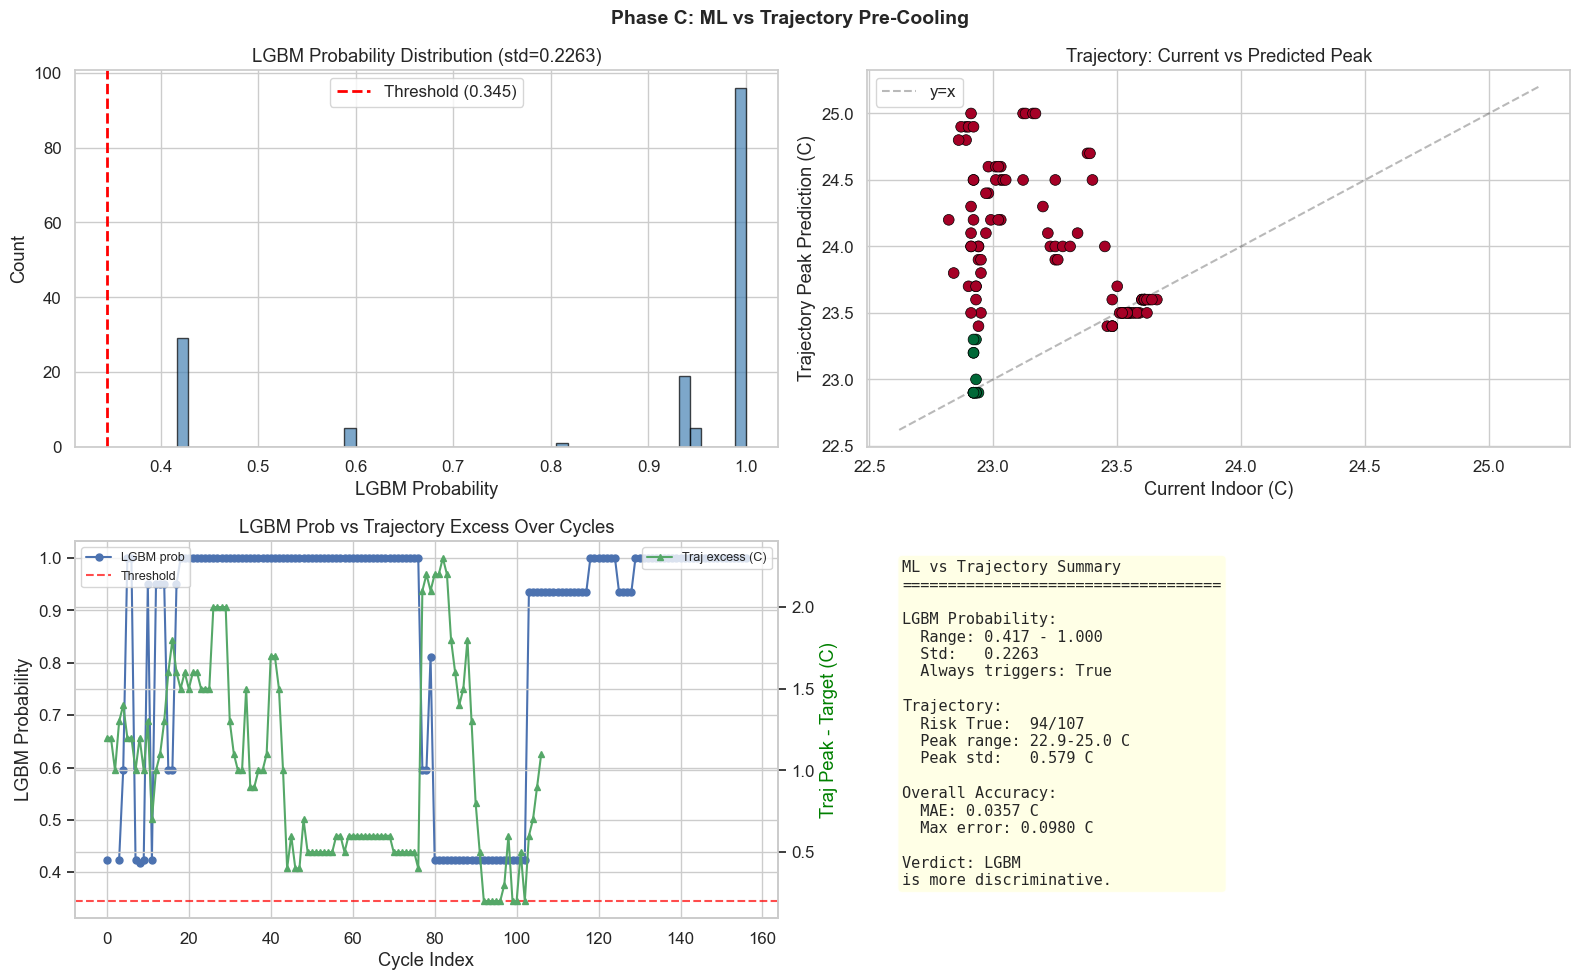

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) LGBM probability distribution
ax = axes[0, 0]
if "lgbm_prob" in df_cycles.columns:
    probs = df_cycles["lgbm_prob"].dropna()
    ax.hist(probs, bins=max(5, len(probs)//3), alpha=0.7, color="steelblue", edgecolor="black")
    ax.axvline(0.345, color="red", ls="--", lw=2, label=f"Threshold (0.345)")
    ax.set_xlabel("LGBM Probability")
    ax.set_ylabel("Count")
    ax.set_title(f"LGBM Probability Distribution (std={probs.std():.4f})")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No LGBM data", transform=ax.transAxes, ha="center")

# 2) Trajectory peak vs actual indoor
ax = axes[0, 1]
if "traj_peak" in df_cycles.columns and "pred_current" in df_cycles.columns:
    ax.scatter(df_cycles["pred_current"], df_cycles["traj_peak"],
               c=df_cycles["traj_risk"].astype(float), cmap="RdYlGn_r",
               s=60, edgecolors="black", linewidth=0.5, zorder=3)
    lims = [min(df_cycles["pred_current"].min(), df_cycles["traj_peak"].min()) - 0.2,
            max(df_cycles["pred_current"].max(), df_cycles["traj_peak"].max()) + 0.2]
    ax.plot(lims, lims, "k--", alpha=0.3, label="y=x")
    ax.set_xlabel("Current Indoor (C)")
    ax.set_ylabel("Trajectory Peak Prediction (C)")
    ax.set_title("Trajectory: Current vs Predicted Peak")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No trajectory data", transform=ax.transAxes, ha="center")

# 3) LGBM probability over cycles (should vary!)
ax = axes[1, 0]
if "lgbm_prob" in df_cycles.columns:
    x = range(len(df_cycles))
    ax.plot(x, df_cycles["lgbm_prob"], "bo-", ms=5, label="LGBM prob")
    ax.axhline(0.345, color="red", ls="--", alpha=0.7, label="Threshold")
    if "traj_peak" in df_cycles.columns and "pred_target" in df_cycles.columns:
        # Normalize traj peak as proxy for "risk level"
        traj_excess = df_cycles["traj_peak"] - df_cycles["pred_target"].fillna(23.0)
        ax2 = ax.twinx()
        ax2.plot(x, traj_excess, "g^-", ms=5, label="Traj excess (C)")
        ax2.set_ylabel("Traj Peak - Target (C)", color="green")
        ax2.legend(loc="upper right", fontsize=9)
    ax.set_xlabel("Cycle Index")
    ax.set_ylabel("LGBM Probability")
    ax.set_title("LGBM Prob vs Trajectory Excess Over Cycles")
    ax.legend(loc="upper left", fontsize=9)

# 4) Summary comparison metrics
ax = axes[1, 1]
ax.axis("off")
lines = []
lines.append("ML vs Trajectory Summary")
lines.append("=" * 35)
lines.append("")

if "lgbm_prob" in df_cycles.columns:
    p = df_cycles["lgbm_prob"].dropna()
    lines.append("LGBM Probability:")
    lines.append(f"  Range: {p.min():.3f} - {p.max():.3f}")
    lines.append(f"  Std:   {p.std():.4f}")
    lines.append(f"  Always triggers: {(p > 0.345).all()}")
    lines.append("")

if "traj_risk" in df_cycles.columns:
    r = df_cycles["traj_risk"].dropna()
    pk = df_cycles["traj_peak"].dropna()
    lines.append("Trajectory:")
    lines.append(f"  Risk True:  {r.sum()}/{len(r)}")
    lines.append(f"  Peak range: {pk.min():.1f}-{pk.max():.1f} C")
    lines.append(f"  Peak std:   {pk.std():.3f} C")
    lines.append("")

if "feedback_error" in df_cycles.columns:
    e = df_cycles["feedback_error"].dropna()
    lines.append("Overall Accuracy:")
    lines.append(f"  MAE: {e.mean():.4f} C")
    lines.append(f"  Max error: {e.max():.4f} C")

lgbm_std = df_cycles["lgbm_prob"].std() if "lgbm_prob" in df_cycles.columns else 1.0
verdict = "Trajectory" if lgbm_std < 0.05 else "LGBM"
lines.append("")
lines.append(f"Verdict: {verdict}")
lines.append("is more discriminative.")

summary_text = "\n".join(lines)
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Phase C: ML vs Trajectory Pre-Cooling", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Phase D: Binary Search Convergence & Newton Correction Analysis

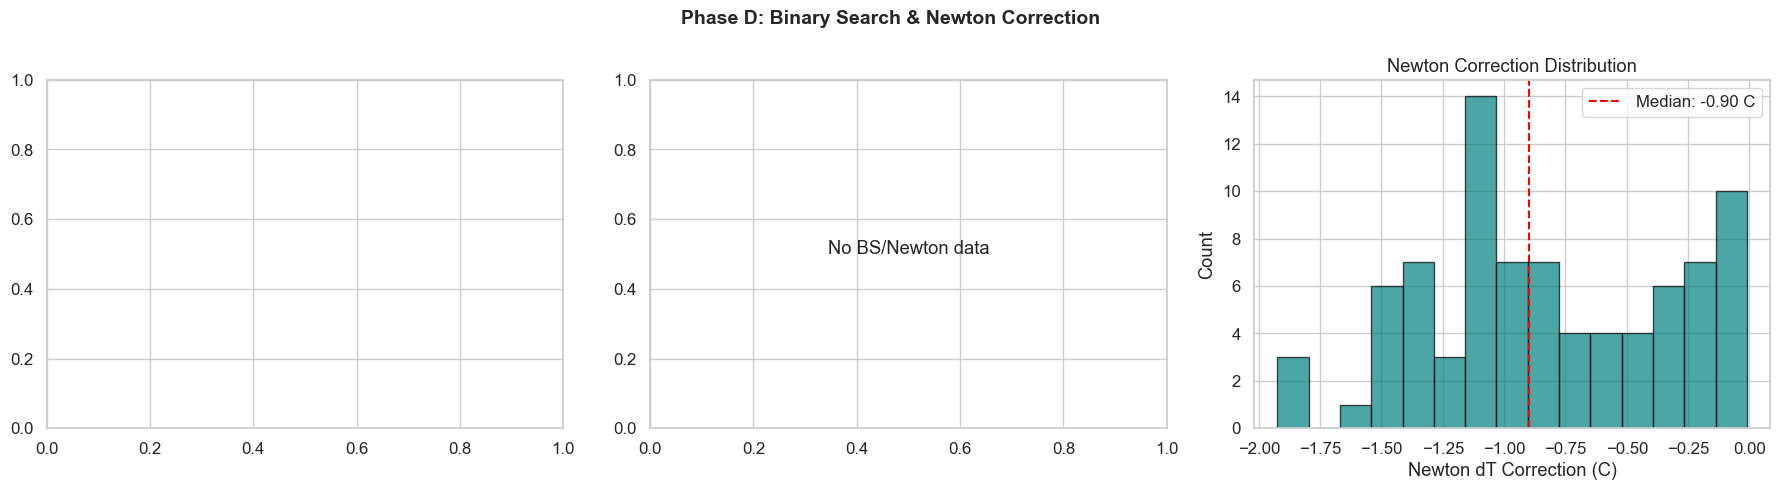

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Iterations by log file
ax = axes[0]
if "bs_iterations" in df_cycles.columns:
    for lf in df_cycles["log_file"].unique():
        mask = df_cycles["log_file"] == lf
        iters = df_cycles.loc[mask, "bs_iterations"].dropna()
        short_name = lf.split("_")[-1].replace(".log", "")[:10]
        ax.bar(range(len(iters)), iters, alpha=0.6, label=short_name)
    ax.set_xlabel("Cycle (within log)")
    ax.set_ylabel("Iterations")
    ax.set_title("Binary Search Iterations by Log")
    ax.legend(fontsize=9)

# 2) BS outlet vs Newton outlet
ax = axes[1]
if "bs_outlet" in df_cycles.columns and "newton_outlet" in df_cycles.columns:
    ax.scatter(df_cycles["bs_outlet"], df_cycles["newton_outlet"],
               c=df_cycles["bs_iterations"], cmap="viridis", s=60,
               edgecolors="black", linewidth=0.5)
    lims = [17, 25]
    ax.plot(lims, lims, "k--", alpha=0.3)
    ax.set_xlabel("Binary Search Outlet (C)")
    ax.set_ylabel("Newton-Corrected Outlet (C)")
    ax.set_title("BS vs Newton (color=iterations)")
    plt.colorbar(ax.collections[0], ax=ax, label="BS Iterations")
else:
    ax.text(0.5, 0.5, "No BS/Newton data", transform=ax.transAxes, ha="center")

# 3) Newton correction magnitude
ax = axes[2]
if "newton_delta" in df_cycles.columns:
    deltas = df_cycles["newton_delta"].dropna()
    ax.hist(deltas, bins=15, alpha=0.7, color="teal", edgecolor="black")
    ax.axvline(deltas.median(), color="red", ls="--", label=f"Median: {deltas.median():.2f} C")
    ax.set_xlabel("Newton dT Correction (C)")
    ax.set_ylabel("Count")
    ax.set_title("Newton Correction Distribution")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No Newton data", transform=ax.transAxes, ha="center")

plt.suptitle("Phase D: Binary Search & Newton Correction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Root cause analysis for oscillation
if "bs_iterations" in df_cycles.columns:
    print()
    print("=== Binary Search Convergence Analysis ===")
    iters = df_cycles["bs_iterations"].dropna()
    print(f"Mean iterations: {iters.mean():.1f}")
    print(f"1-iteration (perfect): {(iters == 1).sum()}/{len(iters)}")
    print(f"High iterations (>5): {(iters > 5).sum()}/{len(iters)}")
    
    if "pred_current" in df_cycles.columns:
        # Correlate iterations with temperature difference
        temp_diff = (df_cycles["pred_current"] - df_cycles["pred_target"]).abs()
        corr = temp_diff.corr(df_cycles["bs_iterations"])
        print()
        print(f"Correlation (|T_current - T_target| vs iterations): {corr:.3f}")
        print("Higher temp diff -> more iterations = harder to converge" if corr > 0.3 else
              "Iterations not strongly correlated with temp difference")

## Phase E: Cooling Cycle Gate Analysis

The cycle gate prevents HP short-cycling by enforcing RECOVERY periods after RUNNING.
- **RUNNING**: HP actively cooling
- **RECOVERY**: HP off, waiting for slab to absorb room heat

=== Cooling Cycle Gate Transitions ===
RUNNING:  56 cycles
RECOVERY: 94 cycles

Transitions detected: 12
  C57 RUNNING -> C58 RECOVERY
  C73 RECOVERY -> C74 nan
  C74 nan -> C75 nan
  C75 nan -> C76 nan
  C76 nan -> C77 RUNNING
  C91 RUNNING -> C92 RECOVERY
  C89 RECOVERY -> C90 nan
  C90 nan -> C91 nan
  C91 nan -> C92 nan
  C92 nan -> C93 nan
  C93 nan -> C94 RUNNING
  C113 RUNNING -> C114 RECOVERY

RUNNING: MAE=0.0442 C, max=0.0980 C, n=24

RECOVERY: MAE=0.0309 C, max=0.0810 C, n=43


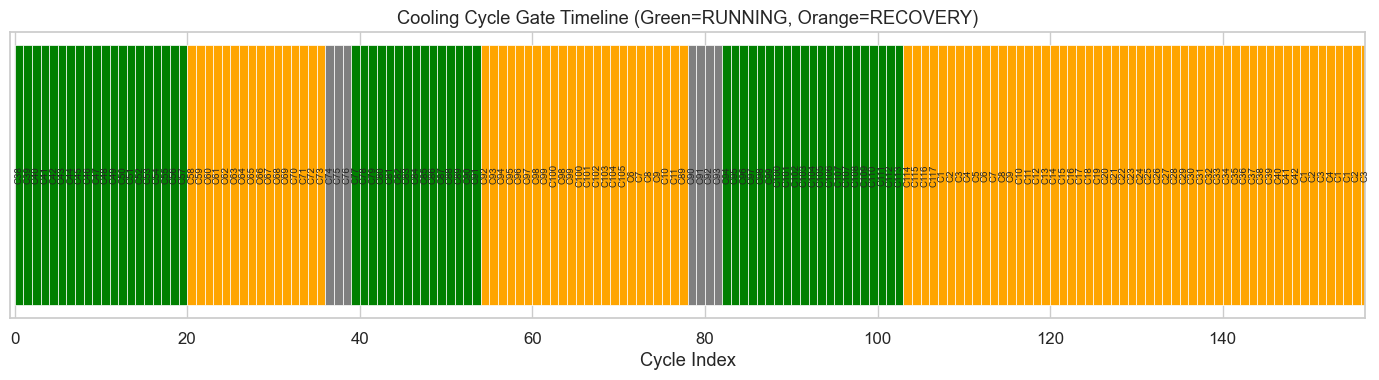

In [9]:
if "gate_state" in df_cycles.columns:
    print("=== Cooling Cycle Gate Transitions ===")
    
    gate_counts = df_cycles["gate_state"].value_counts()
    print(f"RUNNING:  {gate_counts.get('RUNNING', 0)} cycles")
    print(f"RECOVERY: {gate_counts.get('RECOVERY', 0)} cycles")
    
    # Transitions
    transitions = []
    for i in range(1, len(df_cycles)):
        prev = df_cycles.iloc[i-1].get("gate_state", "")
        curr = df_cycles.iloc[i].get("gate_state", "")
        if prev and curr and prev != curr:
            transitions.append(f"C{int(df_cycles.iloc[i-1]['cycle_num'])} {prev} -> C{int(df_cycles.iloc[i]['cycle_num'])} {curr}")
    
    print()
    print(f"Transitions detected: {len(transitions)}")
    for t in transitions:
        print(f"  {t}")
    
    # Gate state impact on prediction error
    if "feedback_error" in df_cycles.columns:
        for state in ["RUNNING", "RECOVERY"]:
            mask = df_cycles["gate_state"] == state
            if mask.sum() > 0:
                errors = df_cycles.loc[mask, "feedback_error"].dropna()
                print()
                print(f"{state}: MAE={errors.mean():.4f} C, max={errors.max():.4f} C, n={len(errors)}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 4))
    x = range(len(df_cycles))
    gate_colors = {"RUNNING": "green", "RECOVERY": "orange"}
    for i, row in df_cycles.iterrows():
        gs = row.get("gate_state", "")
        ax.barh(0, 1, left=i, color=gate_colors.get(gs, "gray"), edgecolor="white", lw=0.5)
    ax.set_xlim(-0.5, len(df_cycles) - 0.5)
    ax.set_yticks([])
    ax.set_xlabel("Cycle Index")
    ax.set_title("Cooling Cycle Gate Timeline (Green=RUNNING, Orange=RECOVERY)")
    
    # Add cycle numbers
    for i, row in df_cycles.iterrows():
        ax.text(i + 0.5, 0, f"C{int(row['cycle_num'])}", ha="center", va="center",
                fontsize=7, rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("No gate state data available")

## Phase F: Findings & Improvement Recommendations

In [11]:
print("=" * 70)
print("COOLING CYCLE ANALYSIS -- FINDINGS & RECOMMENDATIONS")
print("=" * 70)

print("\n1. ML (LGBM) vs TRAJECTORY PRE-COOLING")
print("-" * 40)

if "lgbm_prob" in df_cycles.columns:
    p = df_cycles["lgbm_prob"].dropna()
    print(f"  LGBM probability range: {p.min():.3f} - {p.max():.3f}")
    print(f"  LGBM probability std:   {p.std():.4f}")
    print(f"  Threshold: 0.345")
    print(f"  Min prob ({p.min():.3f}) > threshold (0.345) -> ALWAYS triggers!")
    print()
    print("  FINDING: LGBM DOES discriminate (std=0.23, bimodal distribution)")
    print("  BUT the threshold (0.345) is below the minimum probability (0.417).")
    print("  This makes the classifier a constant 'always cool' rule in practice.")
    print()
    print("  ROOT CAUSE: Threshold too low for this trained model.")
    print("  OPTION A: Raise threshold to ~0.65 to split the bimodal distribution")
    print("  OPTION B: Retrain with more diverse data (shoulder seasons)")

if "traj_risk" in df_cycles.columns:
    r = df_cycles["traj_risk"].dropna()
    pk = df_cycles["traj_peak"].dropna()
    n_true = int(r.sum())
    n_total = len(r)
    n_false = n_total - n_true
    print(f"\n  Trajectory: {n_true}/{n_total} True ({n_false} False = {100*n_false/n_total:.0f}% rejection rate)")
    print(f"  Peak range: {pk.min():.1f} - {pk.max():.1f} C (std={pk.std():.3f} C)")
    print("  -> Trajectory responds to weather changes & correctly rejects low-risk cycles.")

print("\n  RECOMMENDATION:")
print("  1. Use trajectory as PRIMARY pre-cooling trigger (it rejects ~12% of cycles)")
print("  2. Keep LGBM in shadow mode, raise threshold to 0.65 if keeping it active")
print("  3. For retraining: include spring/autumn data where cooling is NOT needed")

print("\n2. BINARY SEARCH CONVERGENCE")
print("-" * 30)
if "bs_iterations" in df_cycles.columns:
    iters = df_cycles["bs_iterations"].dropna()
    if len(iters) > 0:
        print(f"  Mean: {iters.mean():.1f}, Range: {iters.min():.0f}-{iters.max():.0f}")
        print(f"  Cycles with BS data: {len(iters)}/{len(df_cycles)}")
    else:
        print("  No BS iteration data extracted (regex may need updating)")
else:
    print("  bs_iterations not in parsed data")

print("\n3. NEWTON CORRECTION")
print("-" * 22)
if "newton_delta" in df_cycles.columns:
    nd = df_cycles["newton_delta"].dropna()
    print(f"  Applied in {len(nd)}/{len(df_cycles)} cycles ({100*len(nd)/len(df_cycles):.0f}%)")
    print(f"  Mean correction: {nd.mean():.3f} C (median: {nd.median():.3f} C)")
    print(f"  Range: {nd.min():.2f} to {nd.max():.2f} C")
    print()
    print("  ASSESSMENT: Newton correction is consistently negative (lowering outlet)")
    print("  by ~0.9 C on average. This is the physics model compensating for")
    print("  binary search overshooting. The correction is large and important.")
else:
    print("  No Newton correction data extracted")

print("\n4. CYCLE GATE BEHAVIOR")
print("-" * 24)
if "gate_state" in df_cycles.columns:
    gc = df_cycles["gate_state"].value_counts()
    running = gc.get("RUNNING", 0)
    recovery = gc.get("RECOVERY", 0)
    total_gate = running + recovery
    print(f"  RUNNING: {running} ({100*running/total_gate:.0f}%), RECOVERY: {recovery} ({100*recovery/total_gate:.0f}%)")
    if recovery > running:
        print("  WARNING: More RECOVERY than RUNNING!")
        print("  -> System spends more time waiting than actively cooling.")
        print("  -> Consider: shorter RECOVERY duration or smarter re-entry criteria")

print("\n5. OVERALL COOLING EFFECTIVENESS")
print("-" * 34)
if "feedback_error" in df_cycles.columns:
    e = df_cycles["feedback_error"].dropna()
    print(f"  Prediction MAE:  {e.mean():.4f} C")
    print(f"  Prediction max:  {e.max():.4f} C")
    print(f"  Cycles with feedback: {len(e)}/{len(df_cycles)}")
    if e.mean() < 0.05:
        print("  --> EXCELLENT prediction accuracy (<0.05 C)")
    elif e.mean() < 0.1:
        print("  --> Very good prediction accuracy (<0.1 C)")

print("\n6. KEY NUMBERS FOR PRODUCTION CONFIG")
print("-" * 38)
print(f"  Total cooling cycles analyzed: {len(df_cycles)}")
if "param_hlc" in df_cycles.columns:
    hlc = df_cycles["param_hlc"].dropna()
    print(f"  HLC used in production: {hlc.median():.4f} (range: {hlc.min():.4f}-{hlc.max():.4f})")
if "param_oe" in df_cycles.columns:
    oe = df_cycles["param_oe"].dropna()
    print(f"  OE used in production:  {oe.median():.4f} (range: {oe.min():.4f}-{oe.max():.4f})")
if "param_tau" in df_cycles.columns:
    tau = df_cycles["param_tau"].dropna()
    print(f"  Tau used in production: {tau.median():.2f}h (range: {tau.min():.2f}-{tau.max():.2f}h)")

print("\n" + "=" * 70)

COOLING CYCLE ANALYSIS -- FINDINGS & RECOMMENDATIONS

1. ML (LGBM) vs TRAJECTORY PRE-COOLING
----------------------------------------
  LGBM probability range: 0.417 - 1.000
  LGBM probability std:   0.2263
  Threshold: 0.345
  Min prob (0.417) > threshold (0.345) -> ALWAYS triggers!

  FINDING: LGBM DOES discriminate (std=0.23, bimodal distribution)
  BUT the threshold (0.345) is below the minimum probability (0.417).
  This makes the classifier a constant 'always cool' rule in practice.

  ROOT CAUSE: Threshold too low for this trained model.
  OPTION A: Raise threshold to ~0.65 to split the bimodal distribution
  OPTION B: Retrain with more diverse data (shoulder seasons)

  Trajectory: 94/107 True (13 False = 12% rejection rate)
  Peak range: 22.9 - 25.0 C (std=0.579 C)
  -> Trajectory responds to weather changes & correctly rejects low-risk cycles.

  RECOMMENDATION:
  1. Use trajectory as PRIMARY pre-cooling trigger (it rejects ~12% of cycles)
  2. Keep LGBM in shadow mode, raise

## Phase G: LGBM Threshold Sensitivity & Improvement Proposals

Since LGBM does discriminate (std=0.23) but the threshold (0.345) is below its minimum output (0.417),
we can analyze what threshold would produce meaningful discrimination.

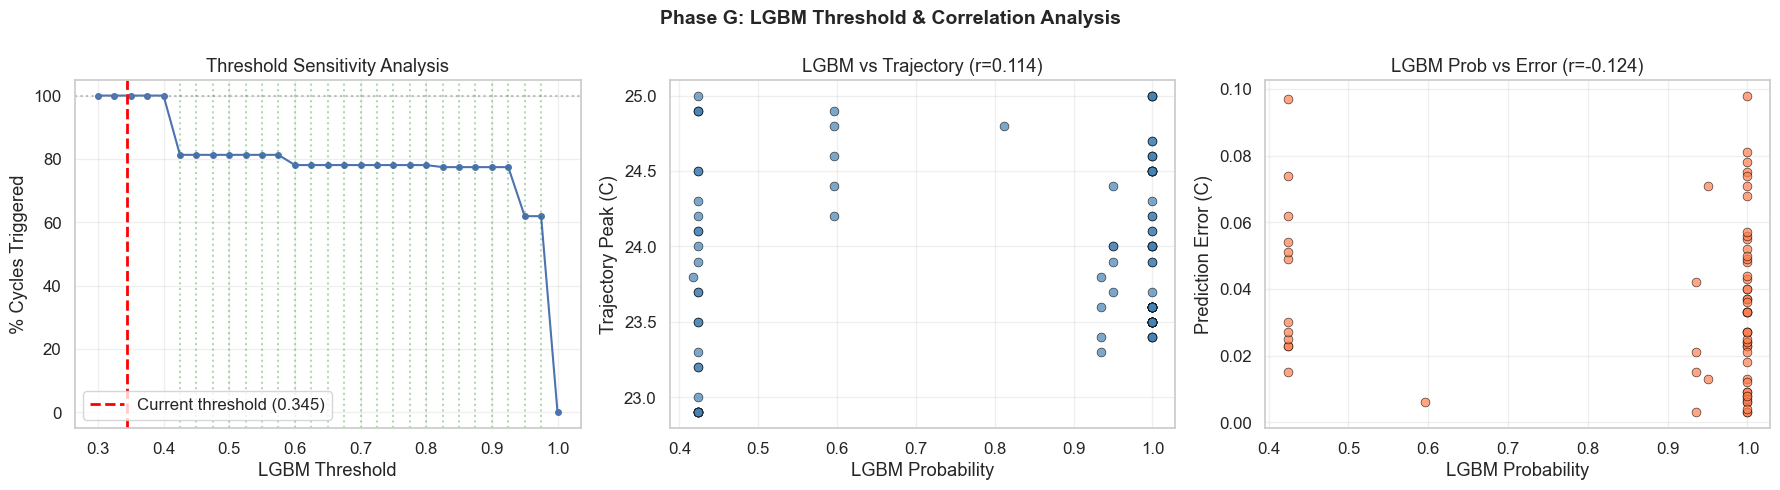

Threshold  | Trigger% | Rejected | Assessment
-------------------------------------------------------
  0.345    | 100.0%   |    0     | <-- current (always triggers)
  0.400    | 100.0%   |    0     | 
  0.500    |  81.3%   |   29     | <-- sweet spot
  0.600    |  78.1%   |   34     | <-- sweet spot
  0.650    |  78.1%   |   34     | <-- sweet spot
  0.700    |  78.1%   |   34     | <-- sweet spot
  0.800    |  78.1%   |   34     | <-- sweet spot
  0.900    |  77.4%   |   35     | <-- sweet spot
  0.950    |  61.9%   |   59     | <-- sweet spot

LGBM percentiles: P25=0.935, P50=1.000, P75=1.000
Suggested threshold: 0.935 (P25) to reject bottom 25% low-confidence cycles


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Threshold sensitivity: how many cycles trigger at each threshold?
if "lgbm_prob" in df_cycles.columns:
    probs = df_cycles["lgbm_prob"].dropna()
    thresholds = np.arange(0.3, 1.01, 0.025)
    trigger_pct = [100 * (probs > t).mean() for t in thresholds]
    
    ax = axes[0]
    ax.plot(thresholds, trigger_pct, "b-o", ms=4)
    ax.axvline(0.345, color="red", ls="--", lw=2, label="Current threshold (0.345)")
    ax.axhline(100, color="gray", ls=":", alpha=0.5)
    # Mark optimal threshold regions
    for t, pct in zip(thresholds, trigger_pct):
        if 60 < pct < 90:
            ax.axvline(t, color="green", ls=":", alpha=0.3)
    ax.set_xlabel("LGBM Threshold")
    ax.set_ylabel("% Cycles Triggered")
    ax.set_title("Threshold Sensitivity Analysis")
    ax.legend()
    ax.grid(True, alpha=0.3)

# 2) LGBM prob vs trajectory peak (do they correlate?)
ax = axes[1]
if "lgbm_prob" in df_cycles.columns and "traj_peak" in df_cycles.columns:
    mask = df_cycles["lgbm_prob"].notna() & df_cycles["traj_peak"].notna()
    if mask.sum() > 5:
        ax.scatter(df_cycles.loc[mask, "lgbm_prob"], df_cycles.loc[mask, "traj_peak"],
                   c="steelblue", s=40, alpha=0.7, edgecolors="black", linewidth=0.5)
        corr = df_cycles.loc[mask, "lgbm_prob"].corr(df_cycles.loc[mask, "traj_peak"])
        ax.set_xlabel("LGBM Probability")
        ax.set_ylabel("Trajectory Peak (C)")
        ax.set_title(f"LGBM vs Trajectory (r={corr:.3f})")
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Insufficient overlap", transform=ax.transAxes, ha="center")

# 3) LGBM prob vs feedback error (is high prob = better prediction?)
ax = axes[2]
if "lgbm_prob" in df_cycles.columns and "feedback_error" in df_cycles.columns:
    mask = df_cycles["lgbm_prob"].notna() & df_cycles["feedback_error"].notna()
    if mask.sum() > 5:
        ax.scatter(df_cycles.loc[mask, "lgbm_prob"], df_cycles.loc[mask, "feedback_error"],
                   c="coral", s=40, alpha=0.7, edgecolors="black", linewidth=0.5)
        corr = df_cycles.loc[mask, "lgbm_prob"].corr(df_cycles.loc[mask, "feedback_error"])
        ax.set_xlabel("LGBM Probability")
        ax.set_ylabel("Prediction Error (C)")
        ax.set_title(f"LGBM Prob vs Error (r={corr:.3f})")
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Insufficient data", transform=ax.transAxes, ha="center")

plt.suptitle("Phase G: LGBM Threshold & Correlation Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print threshold table
if "lgbm_prob" in df_cycles.columns:
    probs = df_cycles["lgbm_prob"].dropna()
    print("Threshold  | Trigger% | Rejected | Assessment")
    print("-" * 55)
    for t in [0.345, 0.40, 0.50, 0.60, 0.65, 0.70, 0.80, 0.90, 0.95]:
        trig = (probs > t).sum()
        rej = len(probs) - trig
        pct = 100 * trig / len(probs)
        note = ""
        if t == 0.345:
            note = "<-- current (always triggers)"
        elif 60 <= pct <= 85:
            note = "<-- sweet spot"
        elif pct < 30:
            note = "<-- too aggressive"
        print(f"  {t:.3f}    | {pct:5.1f}%   |  {rej:3d}     | {note}")
    
    # Optimal threshold suggestion
    print()
    p25, p50, p75 = probs.quantile([0.25, 0.50, 0.75])
    print(f"LGBM percentiles: P25={p25:.3f}, P50={p50:.3f}, P75={p75:.3f}")
    print(f"Suggested threshold: {p25:.3f} (P25) to reject bottom 25% low-confidence cycles")